````
1. Aller sur kaggle.com → ton avatar → Settings
2. Section "API" → cliquer "Create New Token"
3. Un fichier kaggle.json est téléchargé

4. Le placer au bon endroit :

Windows :
move kaggle.json %USERPROFILE%\.kaggle\kaggle.json

Mac / Linux :
mkdir -p ~/.kaggle
mv ~/Downloads/kaggle.json ~/.kaggle/kaggle.json
chmod 600 ~/.kaggle/kaggle.json
````

##### Imports & chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

# Chargement des fichiers
train      = pd.read_csv('../data/train.csv',            parse_dates=['date'])
stores     = pd.read_csv('../data/stores.csv')
holidays   = pd.read_csv('../data/holidays_events.csv',  parse_dates=['date'])
oil        = pd.read_csv('../data/oil.csv',              parse_dates=['date'])
transac    = pd.read_csv('../data/transactions.csv',    parse_dates=['date'])

# Aperçu rapide
print(f"train      : {train.shape}")
print(f"stores     : {stores.shape}")
print(f"holidays   : {holidays.shape}")
print(f"oil        : {oil.shape}")
print(f"transac    : {transac.shape}")
train.head()

train      : (3000888, 6)
stores     : (54, 5)
holidays   : (350, 6)
oil        : (1218, 2)
transac    : (83488, 3)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


##### Fusion des tables

In [3]:
# Fusion avec métadonnées magasins et transactions
df = train.merge(stores,  on='store_nbr',               how='left')
df = df.merge(transac,    on=['date', 'store_nbr'],       how='left')
df = df.merge(oil,        on='date',                      how='left')

# Nettoyage des jours fériés (exclure les jours transférés)
hol = holidays[holidays['transferred'] == False][['date', 'type', 'locale']]
hol = hol.rename(columns={'type': 'holiday_type', 'locale': 'holiday_locale'})
df = df.merge(hol, on='date', how='left')

# Colonne binaire jour férié
df['is_holiday'] = df['holiday_type'].notna().astype('int8')

# Interpoler les valeurs manquantes du prix du pétrole
df['dcoilwtico'] = df['dcoilwtico'].interpolate(method='linear')

print(f"DataFrame maître : {df.shape}")
print(f"Valeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

DataFrame maître : (3054348, 15)
Valeurs manquantes :
transactions       249117
dcoilwtico           1782
holiday_type      2567862
holiday_locale    2567862
dtype: int64


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,holiday_type,holiday_locale,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,1


In [4]:
# Pourquoi des transactions manquantes ?
missing_transac = df[df['transactions'].isnull()]

print(f"Lignes sans transactions : {len(missing_transac)}")
print(f"\nJours de semaine concernés :")
print(missing_transac['date'].dt.day_name().value_counts())
print(f"\nPériode couverte :")
print(missing_transac['date'].describe())

Lignes sans transactions : 249117

Jours de semaine concernés :
date
Sunday       37290
Wednesday    36069
Tuesday      35871
Thursday     35508
Friday       35376
Monday       35013
Saturday     33990
Name: count, dtype: int64

Période couverte :
count                        249117
mean     2014-07-03 22:23:40.161611
min             2013-01-01 00:00:00
25%             2013-08-26 00:00:00
50%             2014-05-11 00:00:00
75%             2015-02-16 00:00:00
max             2017-04-19 00:00:00
Name: date, dtype: object


In [5]:
# Quel magasin est concerné ?
print(df[df['transactions'].isnull()]['store_nbr'].value_counts().head(10))

# Est-ce que les ventes sont aussi à 0 ces jours-là ?
null_tx = df[df['transactions'].isnull()]
print(f"\nVentes nulles quand transactions manquantes : {(null_tx['sales'] == 0).mean()*100:.1f}%")
print(f"Ventes moyennes quand transactions manquantes : {null_tx['sales'].mean():.2f}")

store_nbr
52    52569
22    33891
42    32274
21    31350
29    27093
20    25938
53    17226
36     4389
18     3927
24     3663
Name: count, dtype: int64

Ventes nulles quand transactions manquantes : 98.7%
Ventes moyennes quand transactions manquantes : 9.56


In [6]:
# Vérifier les dates d'ouverture des magasins concernés
stores_null = df[df['transactions'].isnull()]['store_nbr'].value_counts().index.tolist()

for s in stores_null[:5]:
    first_sale = df[(df['store_nbr'] == s) & (df['sales'] > 0)]['date'].min()
    print(f"Magasin {s:>2} — première vente : {first_sale.date()}")

# Traitement : remplacer par 0
df['transactions'] = df['transactions'].fillna(0).astype('int32')

# Vérification finale
print(f"\nValeurs manquantes restantes :")
remaining = df.isnull().sum()
print(remaining[remaining > 0])
print("\nDataFrame prêt ✓" if remaining[remaining > 0].empty else "")

Magasin 52 — première vente : 2017-04-20
Magasin 22 — première vente : 2015-10-09
Magasin 42 — première vente : 2015-08-21
Magasin 21 — première vente : 2015-07-24
Magasin 29 — première vente : 2015-03-20

Valeurs manquantes restantes :
dcoilwtico           1782
holiday_type      2567862
holiday_locale    2567862
dtype: int64



In [7]:
# Combler les NaN restants du pétrole (début/fin de série)
df['dcoilwtico'] = (df['dcoilwtico']
                    .ffill()
                    .bfill())

# Vérification
print(df['dcoilwtico'].isnull().sum())  # doit afficher 0

0


##### Vue d'ensemble des ventes

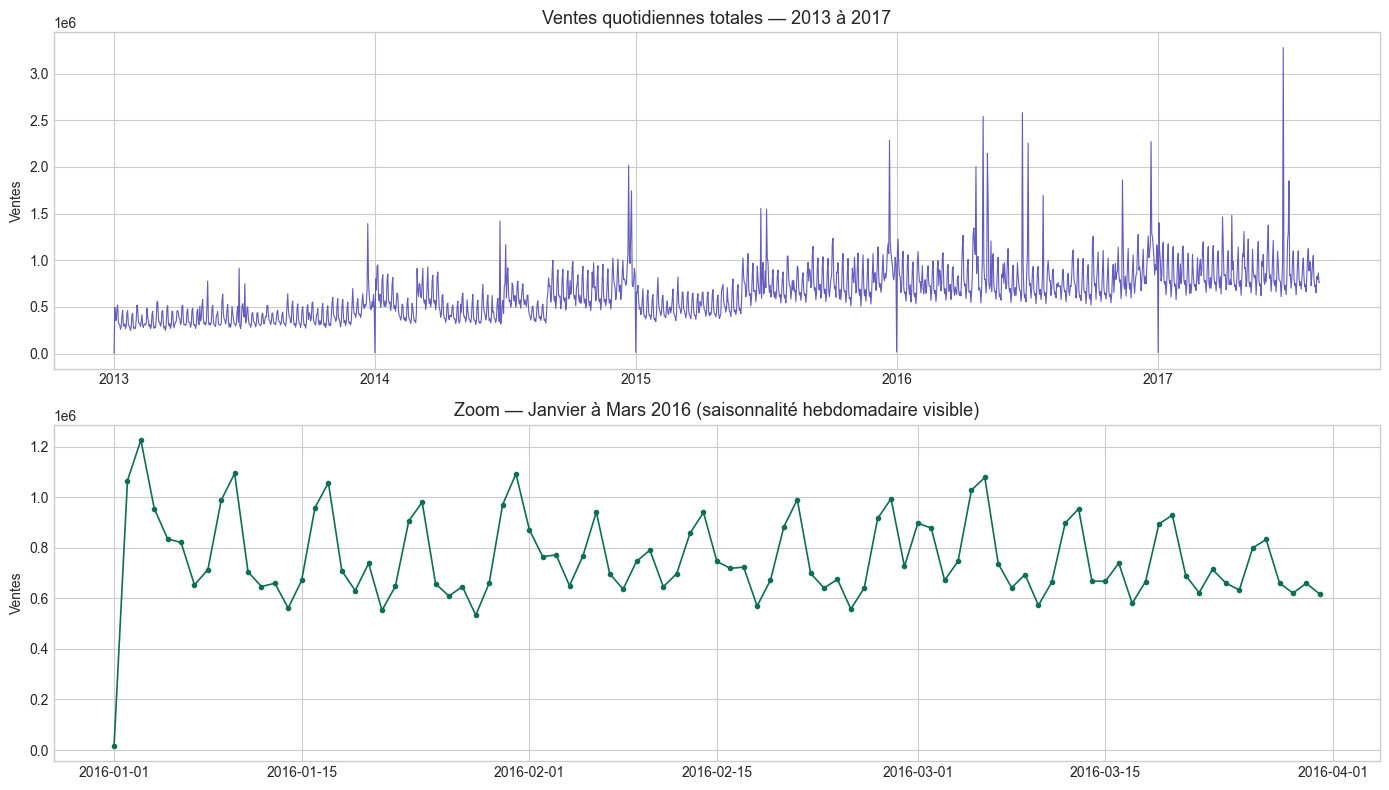

In [8]:
# Ventes totales quotidiennes (tous magasins confondus)
daily_sales = df.groupby('date')['sales'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : série complète
axes[0].plot(daily_sales['date'], daily_sales['sales'],
             color='#534AB7', linewidth=0.8, alpha=0.9)
axes[0].set_title('Ventes quotidiennes totales — 2013 à 2017', fontsize=13)
axes[0].set_ylabel('Ventes')

# Graphique 2 : zoom sur 3 mois pour voir la saisonnalité hebdomadaire
zoom = daily_sales[(daily_sales['date'] >= '2016-01-01') &
                   (daily_sales['date'] <= '2016-03-31')]
axes[1].plot(zoom['date'], zoom['sales'],
             color='#0F6E56', linewidth=1.2, marker='o', markersize=3)
axes[1].set_title('Zoom — Janvier à Mars 2016 (saisonnalité hebdomadaire visible)', fontsize=13)
axes[1].set_ylabel('Ventes')

plt.tight_layout()
plt.savefig('ventes_globales.png', dpi=150, bbox_inches='tight')
plt.show()

##### Analyse par famille de produits

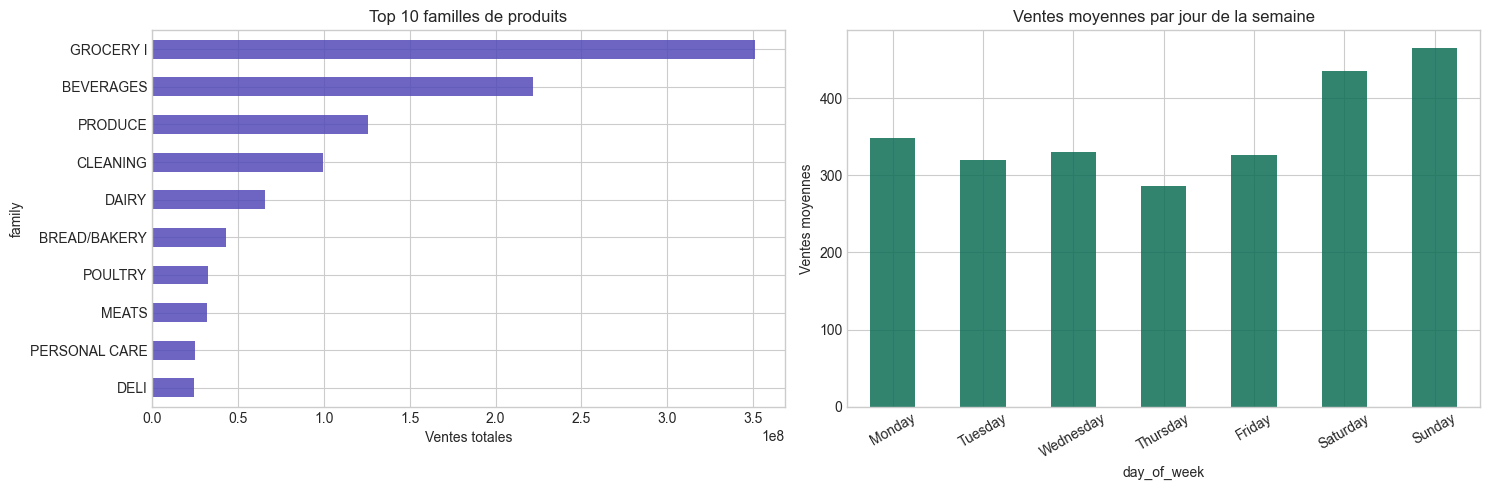

In [9]:
# Top 10 familles par volume de ventes
top_families = (df.groupby('family')['sales']
                .sum()
                .sort_values(ascending=False)
                .head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot top familles
top_families.plot(kind='barh', ax=axes[0], color='#534AB7', alpha=0.85)
axes[0].set_title('Top 10 familles de produits', fontsize=12)
axes[0].set_xlabel('Ventes totales')
axes[0].invert_yaxis()

# Effet jour de la semaine sur les ventes
df['day_of_week'] = df['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = df.groupby('day_of_week')['sales'].mean().reindex(dow_order)
dow_sales.plot(kind='bar', ax=axes[1], color='#0F6E56', alpha=0.85, rot=30)
axes[1].set_title('Ventes moyennes par jour de la semaine', fontsize=12)
axes[1].set_ylabel('Ventes moyennes')

plt.tight_layout()
plt.savefig('analyse_familles_dow.png', dpi=150, bbox_inches='tight')
plt.show()

##### Impact des jours fériés et des promotions

Impact jours fériés sur les ventes : +12.7%
Impact début de mois sur les ventes : +14.2%
Impact promotions sur les ventes : +4663.3%


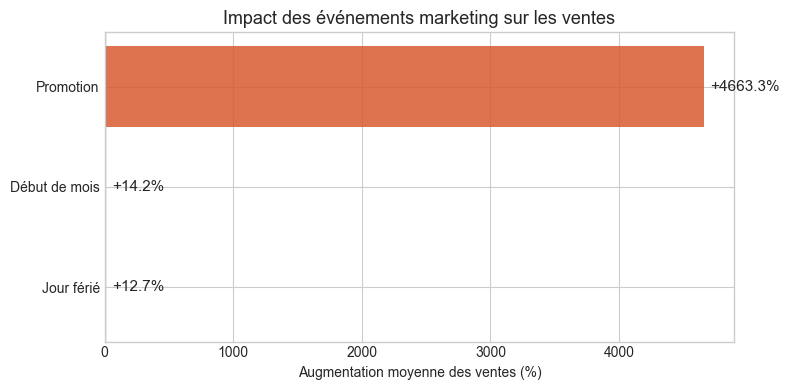

In [10]:
# Effet des jours fériés
holiday_impact = df.groupby('is_holiday')['sales'].agg(['mean', 'median'])
holiday_impact.index = ['Jour normal', 'Jour férié']
lift_pct = (holiday_impact.loc['Jour férié', 'mean'] /
            holiday_impact.loc['Jour normal', 'mean'] - 1) * 100
print(f"Impact jours fériés sur les ventes : +{lift_pct:.1f}%")

# Effet début de mois (effet salaire)
df['day_of_month'] = df['date'].dt.day
df['is_month_start'] = (df['day_of_month'] <= 5).astype(int)
month_start_impact = df.groupby('is_month_start')['sales'].mean()
lift_ms = (month_start_impact[1] / month_start_impact[0] - 1) * 100
print(f"Impact début de mois sur les ventes : +{lift_ms:.1f}%")

# Effet promotions
promo_impact = df.groupby('onpromotion')['sales'].mean()
lift_promo = (promo_impact.iloc[-1] / promo_impact.iloc[0] - 1) * 100
print(f"Impact promotions sur les ventes : +{lift_promo:.1f}%")

# Visualisation combinée
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Jour férié', 'Début de mois', 'Promotion']
lifts  = [lift_pct, lift_ms, lift_promo]
colors = ['#534AB7', '#0F6E56', '#D85A30']
bars = ax.barh(labels, lifts, color=colors, alpha=0.85)
ax.bar_label(bars, fmt='+%.1f%%', padding=4, fontsize=11)
ax.set_title('Impact des événements marketing sur les ventes', fontsize=13)
ax.set_xlabel('Augmentation moyenne des ventes (%)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('impact_marketing.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Vérifier la distribution de onpromotion
print("Distribution onpromotion :")
print(df['onpromotion'].describe())
print(f"\nValeurs uniques (aperçu) : {sorted(df['onpromotion'].unique())[:10]}")

# Correction : traiter en binaire (0 = pas de promo, 1 = au moins 1 produit en promo)
df['has_promotion'] = (df['onpromotion'] > 0).astype(int)

promo_impact_fixed = df.groupby('has_promotion')['sales'].mean()
lift_promo_fixed = (promo_impact_fixed[1] / promo_impact_fixed[0] - 1) * 100

print(f"\nImpact promotions corrigé : +{lift_promo_fixed:.1f}%")
print(f"  → Ventes moyennes sans promo : {promo_impact_fixed[0]:.1f}")
print(f"  → Ventes moyennes avec promo : {promo_impact_fixed[1]:.1f}")

Distribution onpromotion :
count    3.054348e+06
mean     2.617480e+00
std      1.225494e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.410000e+02
Name: onpromotion, dtype: float64

Valeurs uniques (aperçu) : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Impact promotions corrigé : +622.3%
  → Ventes moyennes sans promo : 157.8
  → Ventes moyennes avec promo : 1139.8


In [13]:
# Impact promo sur GROCERY I — magasin 1 uniquement
mask = (df['store_nbr'] == 1) & (df['family'] == 'GROCERY I')
d = df[mask].copy()

promo_g = d.groupby('has_promotion')['sales'].mean()
lift_grocery = (promo_g[1] / promo_g[0] - 1) * 100

print(f"Impact promo sur GROCERY I (magasin 1) : +{lift_grocery:.1f}%")
print(f"  → Sans promo : {promo_g[0]:.1f} unités/jour")
print(f"  → Avec promo : {promo_g[1]:.1f} unités/jour")

# Même calcul pour les 3 meilleures familles
print("\nImpact promo par famille (magasin 1) :")
for fam in ['GROCERY I', 'BEVERAGES', 'PRODUCE']:
    d_fam = df[(df['store_nbr'] == 1) & (df['family'] == fam)]
    if (d_fam['has_promotion'] == 1).sum() > 0:
        g = d_fam.groupby('has_promotion')['sales'].mean()
        if 0 in g.index and 1 in g.index:
            lift = (g[1] / g[0] - 1) * 100
            print(f"  {fam:<15} : +{lift:.1f}%")

Impact promo sur GROCERY I (magasin 1) : +28.2%
  → Sans promo : 1876.0 unités/jour
  → Avec promo : 2404.4 unités/jour

Impact promo par famille (magasin 1) :
  GROCERY I       : +28.2%
  BEVERAGES       : +86.4%
  PRODUCE         : +179.2%


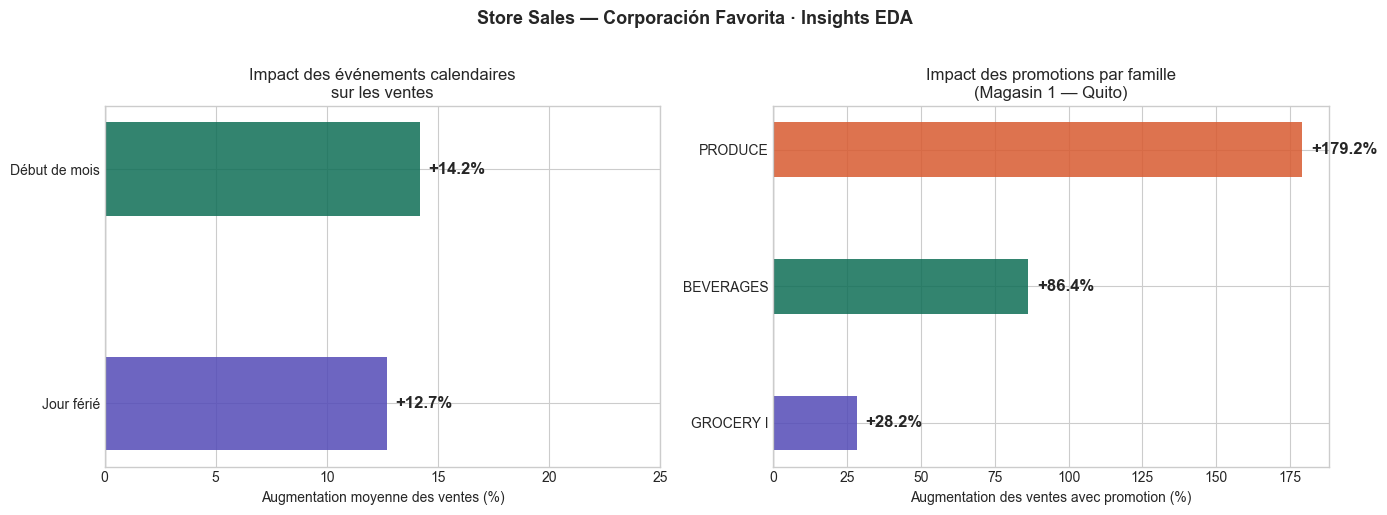


Récapitulatif des insights :
  → Jours fériés       : +12.7% de ventes
  → Début de mois      : +14.2% de ventes
  → Promo GROCERY I    : +28.2% de ventes
  → Promo BEVERAGES    : +86.4% de ventes
  → Promo PRODUCE      : +179.2% de ventes


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : impact des événements calendaires
labels_cal = ['Jour férié', 'Début de mois']
lifts_cal  = [12.7, 14.2]
colors_cal = ['#534AB7', '#0F6E56']
bars = axes[0].barh(labels_cal, lifts_cal, color=colors_cal, alpha=0.85, height=0.4)
axes[0].bar_label(bars, fmt='+%.1f%%', padding=6, fontsize=12, fontweight='bold')
axes[0].set_title('Impact des événements calendaires\nsur les ventes', fontsize=12)
axes[0].set_xlabel('Augmentation moyenne des ventes (%)')
axes[0].set_xlim(0, 25)
axes[0].axvline(0, color='black', linewidth=0.8)

# Graphique 2 : impact des promotions par famille
labels_promo = ['GROCERY I', 'BEVERAGES', 'PRODUCE']
lifts_promo  = [28.2, 86.4, 179.2]
colors_promo = ['#534AB7', '#0F6E56', '#D85A30']
bars2 = axes[1].barh(labels_promo, lifts_promo, color=colors_promo, alpha=0.85, height=0.4)
axes[1].bar_label(bars2, fmt='+%.1f%%', padding=6, fontsize=12, fontweight='bold')
axes[1].set_title('Impact des promotions par famille\n(Magasin 1 — Quito)', fontsize=12)
axes[1].set_xlabel('Augmentation des ventes avec promotion (%)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Store Sales — Corporación Favorita · Insights EDA', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('impact_marketing_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRécapitulatif des insights :")
print(f"  → Jours fériés       : +12.7% de ventes")
print(f"  → Début de mois      : +14.2% de ventes")  
print(f"  → Promo GROCERY I    : +28.2% de ventes")
print(f"  → Promo BEVERAGES    : +86.4% de ventes")
print(f"  → Promo PRODUCE      : +179.2% de ventes")